Installing LIME

In [ ]:
!pip install lime

SECTION 1 — Install & Import All Libraries

In [ ]:
# ─────────────────────────────────────────────
# SECTION 1: Install & Import Libraries
# ─────────────────────────────────────────────

# Install LIME (only missing library in Colab)
!pip install lime -q

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn — Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Scikit-learn — Preprocessing & Evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, classification_report)

# LIME
import lime
import lime.lime_tabular

print("All libraries imported successfully!")

All libraries imported successfully!


SECTION 2 — Load Dataset & EDA

In [ ]:
# ─────────────────────────────────────────────
# SECTION 2: Load Dataset & Explore
# ─────────────────────────────────────────────

# Load Cleveland Heart Disease dataset directly from URL
url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
df = pd.read_csv(url)

print("Dataset loaded!")
print(f" Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset loaded!
 Shape: 303 rows × 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
# Column descriptions
print("""
📋 COLUMN GUIDE:
─────────────────────────────────────────
age      → Patient age
sex      → 1=Male, 0=Female
cp       → Chest pain type (0-3)
trestbps → Resting blood pressure
chol     → Cholesterol level (mg/dl)
fbs      → Fasting blood sugar > 120 (1=True)
restecg  → Resting ECG results (0-2)
thalach  → Max heart rate achieved
exang    → Exercise induced angina (1=Yes)
oldpeak  → ST depression
slope    → Slope of peak ST segment
ca       → No. of major vessels (0-3)
thal     → Thalassemia (0-3)
target   → 0=No Disease, 1=Heart Disease ← PREDICT THIS
─────────────────────────────────────────
""")


📋 COLUMN GUIDE:
─────────────────────────────────────────
age      → Patient age
sex      → 1=Male, 0=Female
cp       → Chest pain type (0-3)
trestbps → Resting blood pressure
chol     → Cholesterol level (mg/dl)
fbs      → Fasting blood sugar > 120 (1=True)
restecg  → Resting ECG results (0-2)
thalach  → Max heart rate achieved
exang    → Exercise induced angina (1=Yes)
oldpeak  → ST depression
slope    → Slope of peak ST segment
ca       → No. of major vessels (0-3)
thal     → Thalassemia (0-3)
target   → 0=No Disease, 1=Heart Disease ← PREDICT THIS
─────────────────────────────────────────



In [ ]:
# Check data types and missing values
print("Data Info:")
print(df.info())
print("\n Missing Values:")
print(df.isnull().sum())
print("\n Statistical Summary:")
df.describe().round(2)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None

 Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
tar

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


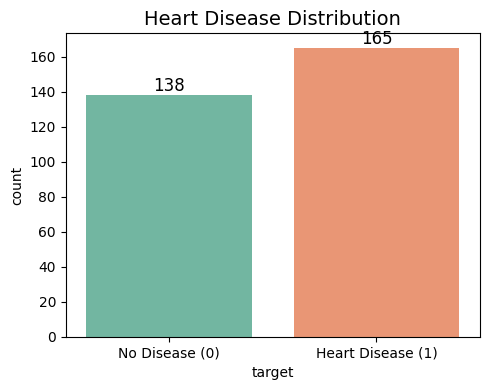

In [ ]:
# ── Visualisation 1: Class Distribution ──────
plt.figure(figsize=(5,4))
ax = sns.countplot(x='target', data=df, palette='Set2')
plt.title('Heart Disease Distribution', fontsize=14)
plt.xticks([0,1], ['No Disease (0)', 'Heart Disease (1)'])
# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

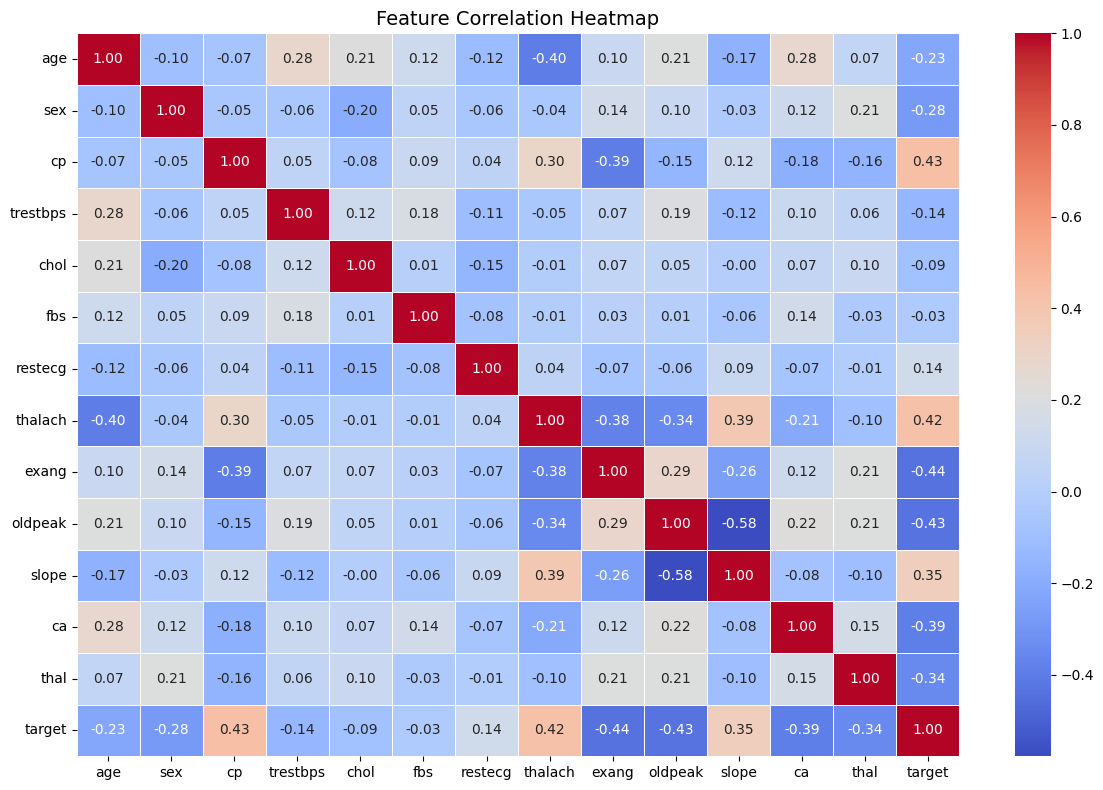

In [ ]:
# ── Visualisation 2: Correlation Heatmap ─────
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

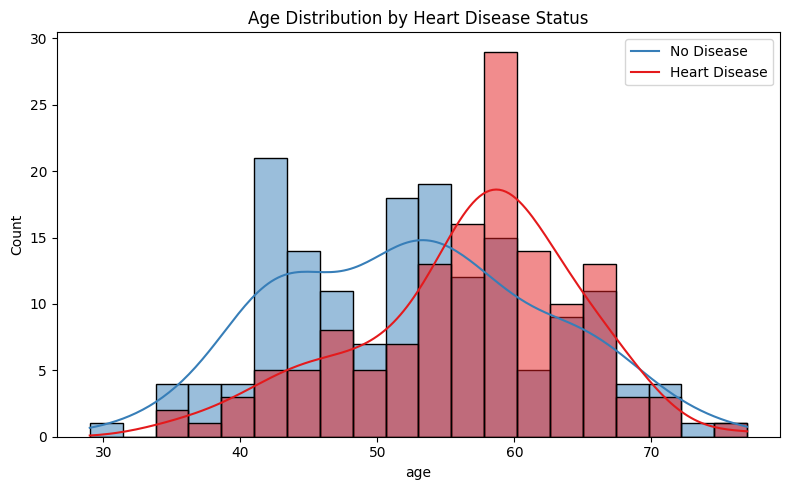

In [ ]:
# ── Visualisation 3: Age distribution ────────
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', hue='target',
             kde=True, palette='Set1', bins=20)
plt.title('Age Distribution by Heart Disease Status')
plt.legend(['No Disease', 'Heart Disease'])
plt.tight_layout()
plt.show()

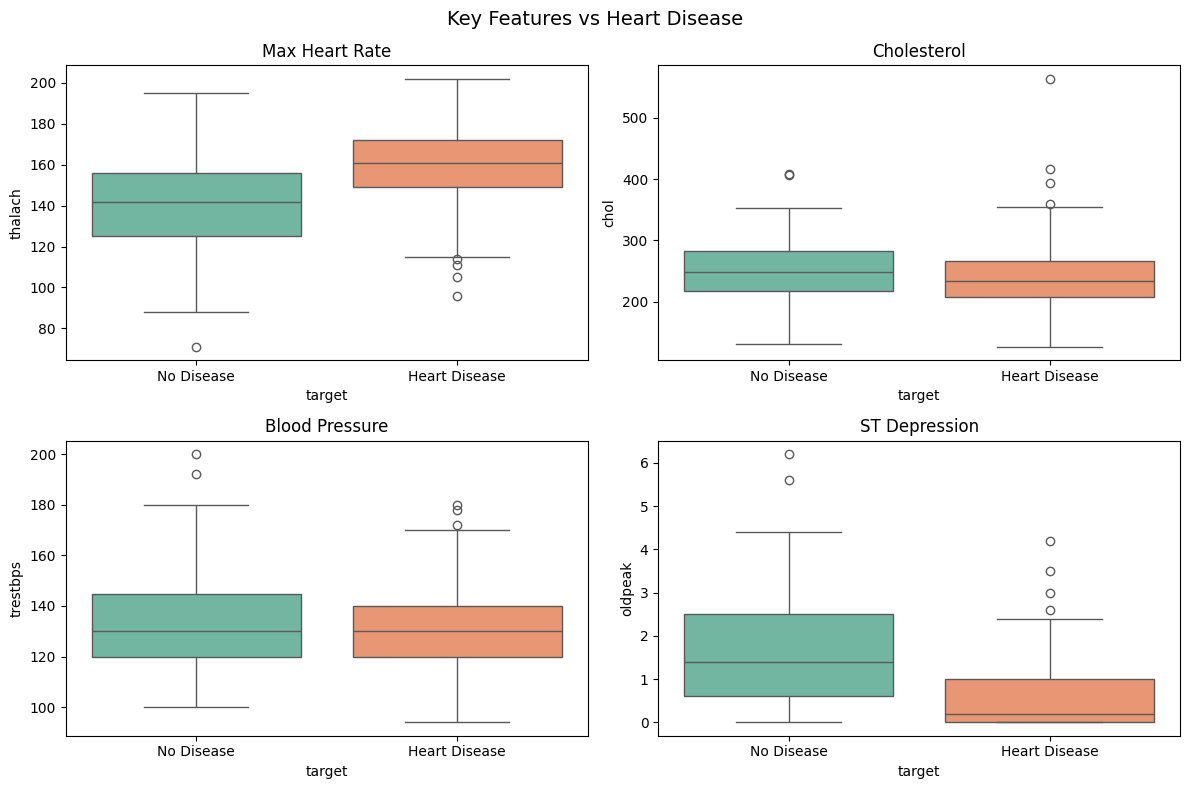

In [ ]:
# ── Visualisation 4: Key Feature Boxplots ────
fig, axes = plt.subplots(2, 2, figsize=(12,8))
features = ['thalach', 'chol', 'trestbps', 'oldpeak']
titles   = ['Max Heart Rate', 'Cholesterol',
            'Blood Pressure', 'ST Depression']

for ax, feat, title in zip(axes.flatten(), features, titles):
    sns.boxplot(x='target', y=feat, data=df,
                ax=ax, palette='Set2')
    ax.set_title(title)
    ax.set_xticklabels(['No Disease', 'Heart Disease'])

plt.suptitle('Key Features vs Heart Disease', fontsize=14)
plt.tight_layout()
plt.show()

SECTION 3 — Data Preprocessing

In [ ]:
# ─────────────────────────────────────────────
# SECTION 3: Data Preprocessing
# ─────────────────────────────────────────────

# ── Step 1: Separate Features and Target ─────
X = df.drop('target', axis=1)   # All columns except target
y = df['target']                 # Only target column

print(f"Features (X) shape: {X.shape}")
print(f"Target   (y) shape: {y.shape}")
print(f"Feature names: {list(X.columns)}")

Features (X) shape: (303, 13)
Target   (y) shape: (303,)
Feature names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [ ]:
# ── Step 2: Train-Test Split ──────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,     # 80% train, 20% test
    random_state = 42,      # Same split every run
    stratify     = y        # Keep class balance
)

print(f" Split complete!")
print(f"   Training samples : {X_train.shape[0]}")
print(f"   Testing  samples : {X_test.shape[0]}")
print(f"\n   Train class balance:\n{y_train.value_counts().to_string()}")
print(f"\n   Test  class balance:\n{y_test.value_counts().to_string()}")

 Split complete!
   Training samples : 242
   Testing  samples : 61

   Train class balance:
target
1    132
0    110

   Test  class balance:
target
1    33
0    28


In [ ]:
# ── Step 3: Feature Scaling ───────────────────
# Scale AFTER split to avoid data leakage!
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # Learn + transform
X_test_scaled  = scaler.transform(X_test)        # Only transform

feature_names = list(X.columns)

print(" Scaling complete!")
print(f"   Before scaling — age mean: {X_train['age'].mean():.1f}")
print(f"   After  scaling — age mean: {X_train_scaled[:,0].mean():.4f}")

 Scaling complete!
   Before scaling — age mean: 54.3
   After  scaling — age mean: 0.0000


SECTION 4 — Build All 4 Models

In [ ]:
# ─────────────────────────────────────────────
# SECTION 4: Train All 4 Models
# ─────────────────────────────────────────────

# ── Model 1: Decision Tree ────────────────────
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_scaled, y_train)
print("Model 1: Decision Tree       — Trained!")

# ── Model 2: Naive Bayes ──────────────────────
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
print("Model 2: Naive Bayes         — Trained!")

# ── Model 3: Logistic Regression ─────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
print("Model 3: Logistic Regression — Trained!")

# ── Model 4: KNN ──────────────────────────────
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
print("Model 4: KNN                 — Trained!")

# Store all models in a dictionary
models = {
    'Decision Tree'       : dt,
    'Naive Bayes'         : nb,
    'Logistic Regression' : lr,
    'KNN'                 : knn
}
print("\n All 4 models trained and ready!")

Model 1: Decision Tree       — Trained!
Model 2: Naive Bayes         — Trained!
Model 3: Logistic Regression — Trained!
Model 4: KNN                 — Trained!

 All 4 models trained and ready!


SECTION 5 — Evaluate & Compare All Models

In [ ]:
# ─────────────────────────────────────────────
# SECTION 5: Model Evaluation
# ─────────────────────────────────────────────

# ── Step 1: Metrics Table ─────────────────────
results = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred),  4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred),    4),
        'F1-Score' : round(f1_score(y_test, y_pred),        4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob),   4)
    })

results_df = pd.DataFrame(results).set_index('Model')
print(" Model Performance Summary:")
print(results_df.to_string())

 Model Performance Summary:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Decision Tree          0.7869     0.7500  0.9091    0.8219   0.8176
Naive Bayes            0.8197     0.7895  0.9091    0.8451   0.8755
Logistic Regression    0.8033     0.7692  0.9091    0.8333   0.8690
KNN                    0.8033     0.7692  0.9091    0.8333   0.8631


In [ ]:
# ── Step 2: Highlight Best Model ─────────────
best_model = results_df['F1-Score'].idxmax()
print(f"\n Best Model (by F1-Score): {best_model}")
print(f"   F1-Score : {results_df.loc[best_model, 'F1-Score']}")
print(f"   Accuracy : {results_df.loc[best_model, 'Accuracy']}")
print(f"   ROC-AUC  : {results_df.loc[best_model, 'ROC-AUC']}")


 Best Model (by F1-Score): Naive Bayes
   F1-Score : 0.8451
   Accuracy : 0.8197
   ROC-AUC  : 0.8755


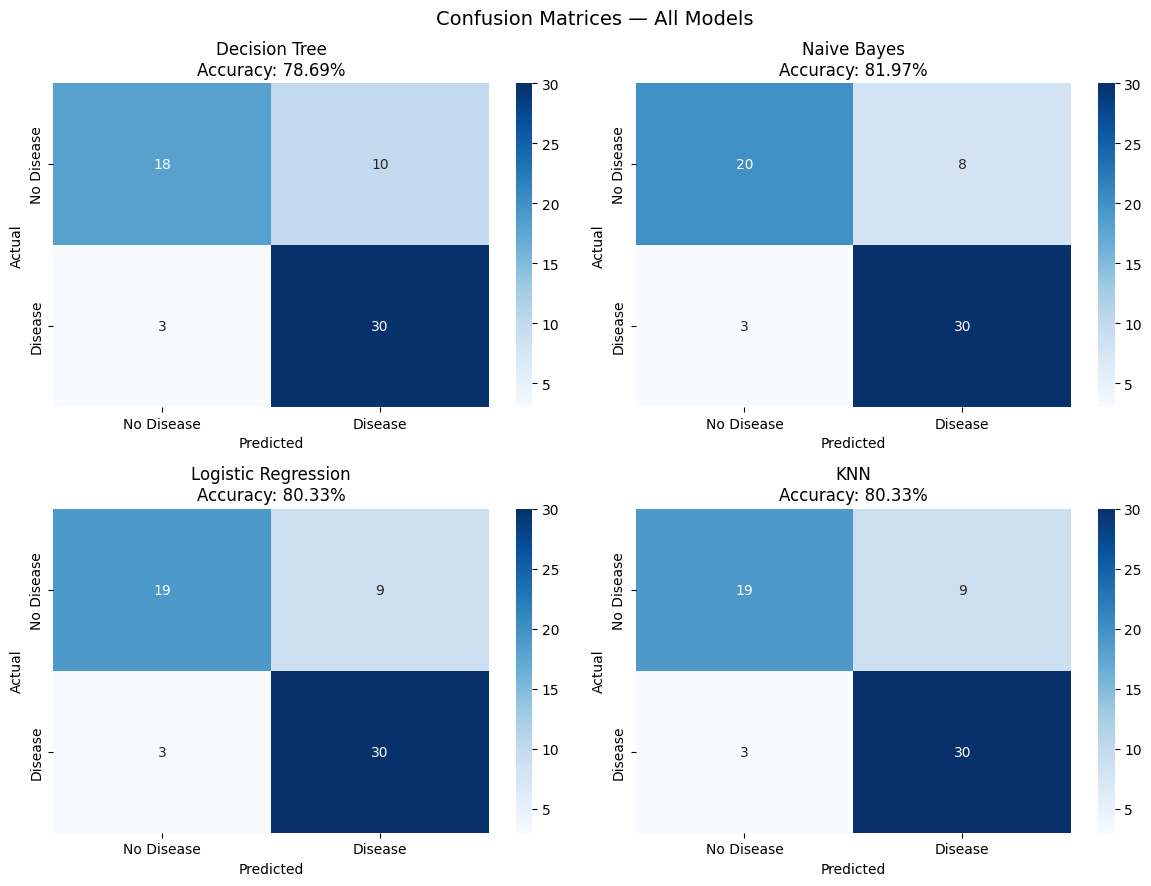

In [ ]:
# ── Step 3: Confusion Matrices ────────────────
fig, axes = plt.subplots(2, 2, figsize=(12,9))
for ax, (name, model) in zip(axes.flatten(), models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease','Disease'],
                yticklabels=['No Disease','Disease'])
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name}\nAccuracy: {acc:.2%}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices — All Models', fontsize=14)
plt.tight_layout()
plt.show()

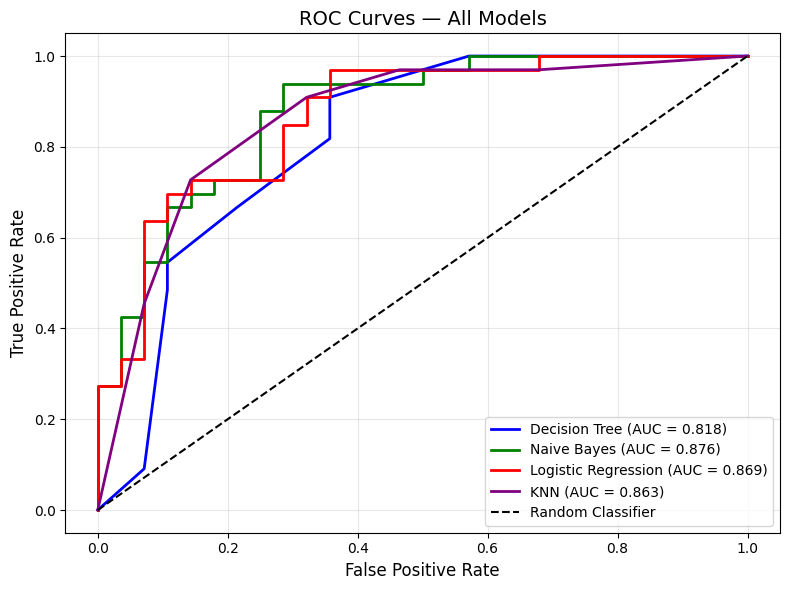

In [ ]:
# ── Step 4: ROC Curves ────────────────────────
plt.figure(figsize=(8,6))
colors = ['blue','green','red','purple']
for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {auc:.3f})')
plt.plot([0,1],[0,1],'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

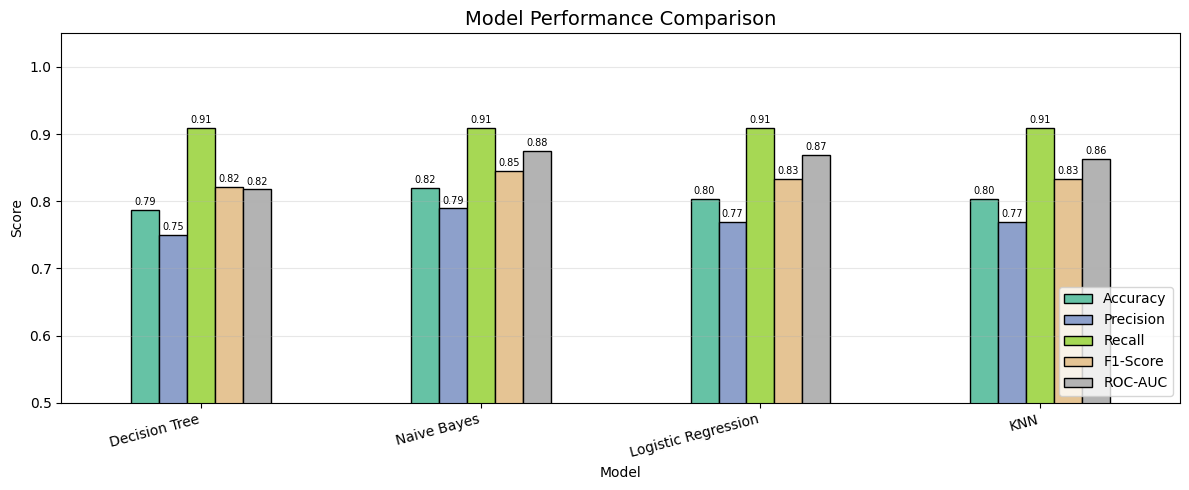

In [ ]:
# ── Step 5: Model Comparison Bar Chart ────────
ax = results_df.plot(kind='bar', figsize=(12,5),
                     colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison', fontsize=14)
plt.xticks(rotation=15, ha='right')
plt.ylabel('Score')
plt.ylim(0.5, 1.05)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
# Add value labels on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2)
plt.tight_layout()
plt.show()

SECTION 6 — LIME Explainability

In [ ]:
# ─────────────────────────────────────────────
# SECTION 6: LIME — Explainable AI
# ─────────────────────────────────────────────

# ── Step 1: Create LIME Explainer ────────────
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_scaled,
    feature_names = feature_names,
    class_names   = ['No Disease', 'Heart Disease'],
    mode          = 'classification',
    random_state  = 42
)
print("LIME Explainer ready!")

LIME Explainer ready!


In [ ]:
# ── Step 2: Pick a patient & explain ─────────
patient_index = 59   #  Change this to any number (0 to 60)
patient       = X_test_scaled[patient_index]
actual_label  = list(y_test)[patient_index]

print(f" Patient Index : {patient_index}")
print(f" Actual Label  : {'Heart Disease' if actual_label==1 else 'No Disease'}")
print()

for name, model in models.items():
    pred = model.predict([patient])[0]
    prob = model.predict_proba([patient])[0][1]
    status = "Correct" if pred == actual_label else "Wrong"
    print(f"{name:25s} → {'Heart Disease' if pred==1 else 'No Disease':15s} "
          f"(confidence: {prob:.1%})  {status}")

 Patient Index : 59
 Actual Label  : No Disease

Decision Tree             → No Disease      (confidence: 0.0%)  Correct
Naive Bayes               → No Disease      (confidence: 0.3%)  Correct
Logistic Regression       → No Disease      (confidence: 3.3%)  Correct
KNN                       → No Disease      (confidence: 20.0%)  Correct


In [ ]:
# ── Step 3: LIME explanation for best model ───
best_model_obj = models[best_model]

exp = explainer.explain_instance(
    data_row   = patient,
    predict_fn = best_model_obj.predict_proba,
    num_features = 10
)

print(f"\n LIME Explanation for {best_model}:")
print(f"{'Feature Condition':<40} {'Impact':>10}")
print("─" * 52)
for feat, weight in exp.as_list():
    direction = "pushes to DISEASE" if weight > 0 else "pushes to NO disease"
    print(f"{feat:<40} {weight:+.4f}  {direction}")


 LIME Explanation for Naive Bayes:
Feature Condition                            Impact
────────────────────────────────────────────────────
-0.72 < exang <= 1.40                    -0.2831  pushes to NO disease
thalach <= -0.59                         -0.2334  pushes to NO disease
-0.67 < slope <= 0.95                    +0.2312  pushes to DISEASE
-0.56 < thal <= 1.10                     -0.2234  pushes to NO disease
-0.89 < oldpeak <= -0.23                 +0.1737  pushes to DISEASE
cp <= -0.94                              -0.1425  pushes to NO disease
ca <= -0.71                              +0.1085  pushes to DISEASE
trestbps > 0.46                          -0.1036  pushes to NO disease
fbs <= -0.40                             +0.0620  pushes to DISEASE
0.13 < age <= 0.73                       -0.0585  pushes to NO disease


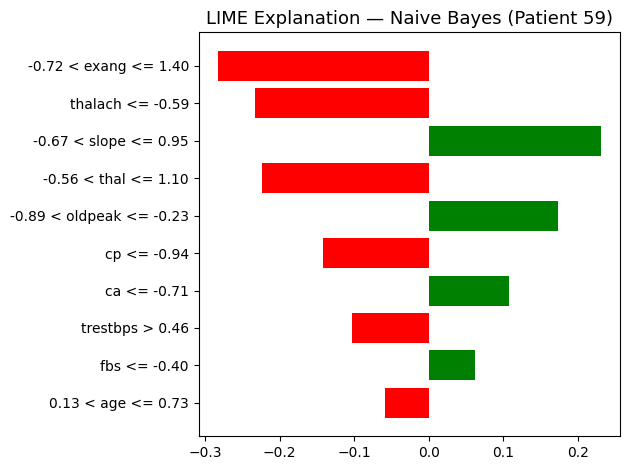

In [ ]:
# ── Step 4: LIME Bar Chart (Best Model) ───────
fig = exp.as_pyplot_figure()
plt.title(f'LIME Explanation — {best_model} (Patient {patient_index})',
          fontsize=13)
plt.tight_layout()
plt.show()

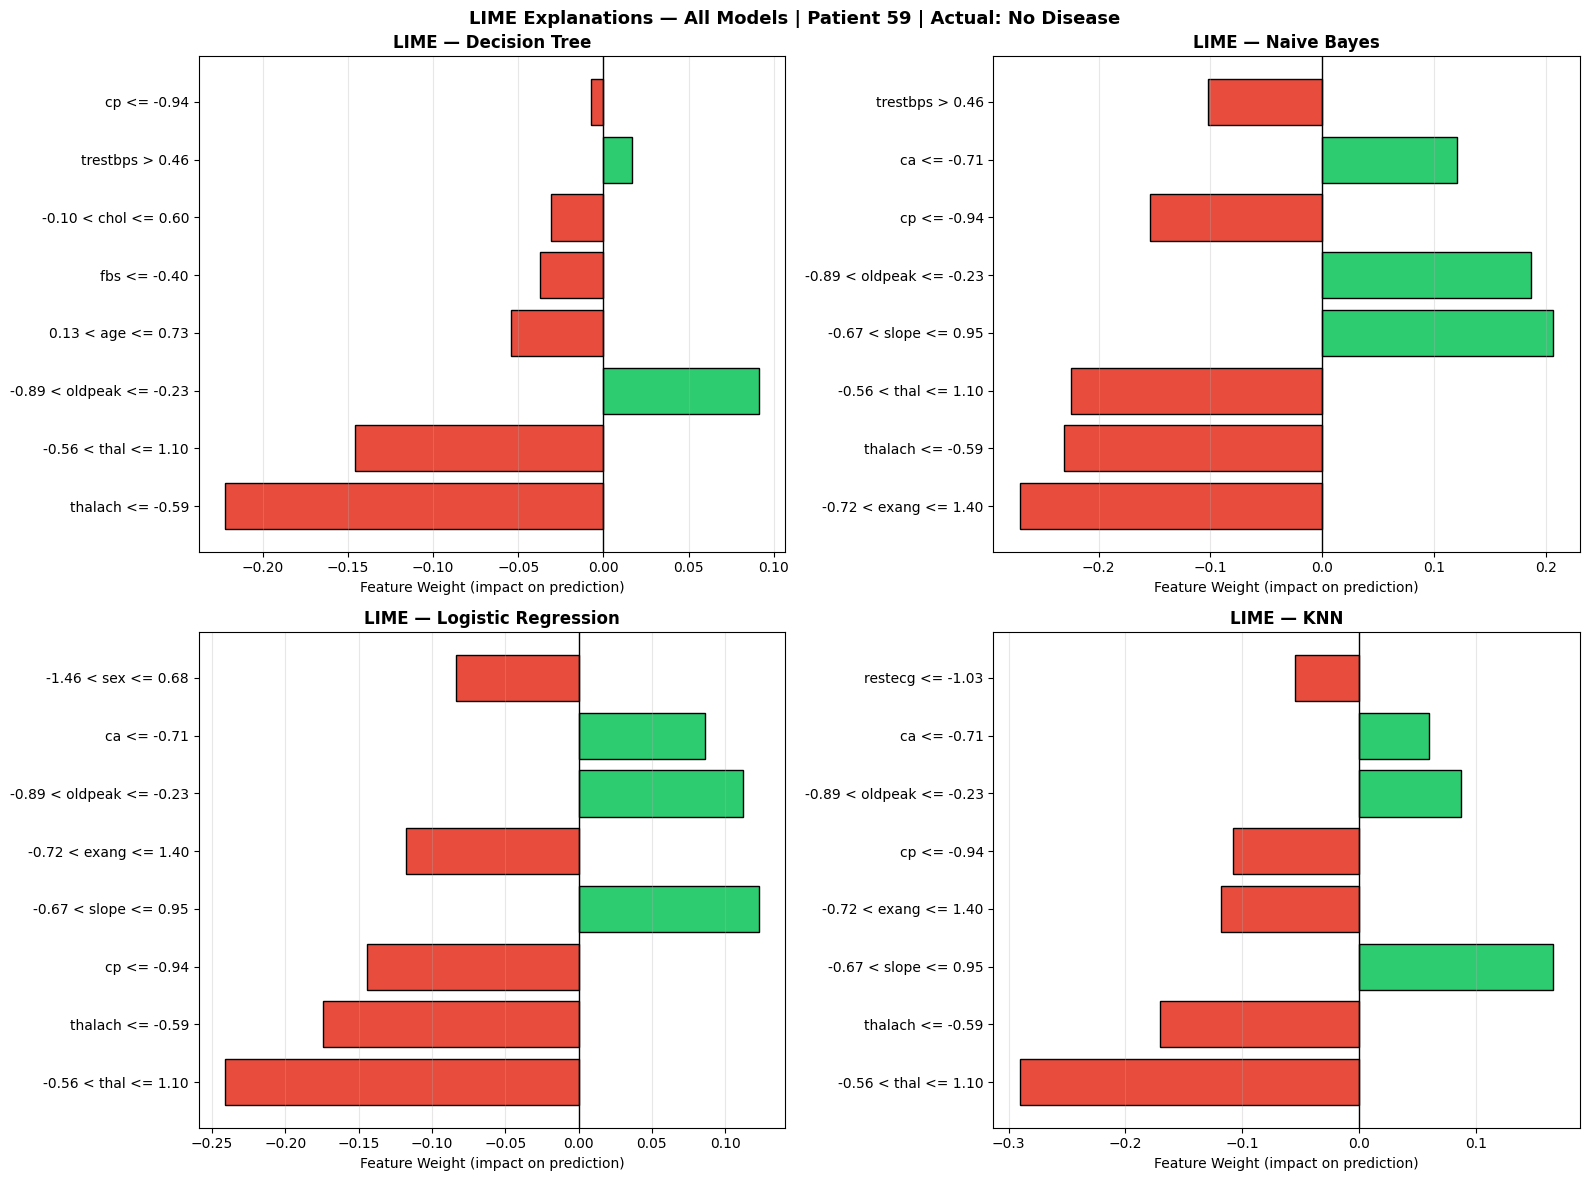


 Green = pushes prediction toward HEART DISEASE
 Red   = pushes prediction toward NO DISEASE


In [ ]:
# ── Step 5: LIME for ALL 4 Models ────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, (name, model) in zip(axes.flatten(), models.items()):
    exp = explainer.explain_instance(
        data_row     = patient,
        predict_fn   = model.predict_proba,
        num_features = 8
    )
    feat_names, weights = zip(*exp.as_list())
    colors = ['#2ecc71' if w > 0 else '#e74c3c' for w in weights]

    bars = ax.barh(feat_names, weights, color=colors, edgecolor='black')
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f'LIME — {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature Weight (impact on prediction)')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle(
    f'LIME Explanations — All Models | Patient {patient_index} | '
    f"Actual: {'Heart Disease' if actual_label==1 else 'No Disease'}",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print("\n Green = pushes prediction toward HEART DISEASE")
print(" Red   = pushes prediction toward NO DISEASE")

SECTION 7 — Cross Validation (K-Fold)

In [ ]:
# ─────────────────────────────────────────────
# SECTION 7: Cross Validation (K-Fold)
# ─────────────────────────────────────────────

from sklearn.model_selection import cross_val_score, StratifiedKFold

# ── Setup K-Fold ──────────────────────────────
kfold = StratifiedKFold(
    n_splits    = 10,      # Split data into 10 parts
    shuffle     = True,
    random_state= 42
)

print(" 10-Fold Cross Validation Results:")
print("=" * 55)

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv      = kfold,
        scoring = 'accuracy'
    )
    cv_results[name] = scores
    print(f"\n {name}")
    print(f"   Fold Scores : {[round(s,3) for s in scores]}")
    print(f"   Mean        : {scores.mean():.4f}  ← Average accuracy")
    print(f"   Std Dev     : {scores.std():.4f}   ← Lower is more stable")

print("\n" + "=" * 55)
print(" Cross Validation Complete!")

 10-Fold Cross Validation Results:

 Decision Tree
   Fold Scores : [np.float64(0.72), np.float64(0.76), np.float64(0.833), np.float64(0.792), np.float64(0.667), np.float64(0.75), np.float64(0.625), np.float64(0.667), np.float64(0.917), np.float64(0.75)]
   Mean        : 0.7480  ← Average accuracy
   Std Dev     : 0.0818   ← Lower is more stable

 Naive Bayes
   Fold Scores : [np.float64(0.92), np.float64(0.8), np.float64(0.875), np.float64(0.917), np.float64(0.583), np.float64(0.667), np.float64(0.875), np.float64(0.792), np.float64(0.875), np.float64(0.875)]
   Mean        : 0.8178  ← Average accuracy
   Std Dev     : 0.1059   ← Lower is more stable

 Logistic Regression
   Fold Scores : [np.float64(0.92), np.float64(0.68), np.float64(0.833), np.float64(0.958), np.float64(0.667), np.float64(0.75), np.float64(0.958), np.float64(0.75), np.float64(0.917), np.float64(0.833)]
   Mean        : 0.8267  ← Average accuracy
   Std Dev     : 0.1051   ← Lower is more stable

 KNN
   Fold Scores 

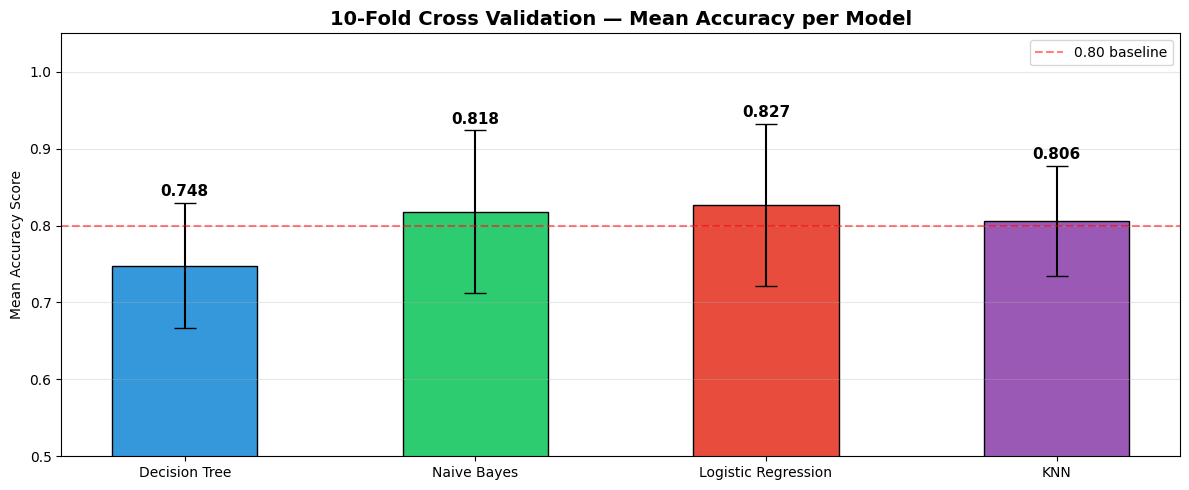


💡 Error bars show stability — smaller bar = more reliable model!


In [ ]:
# ── Cross Validation Comparison Chart ────────
import numpy as np

fig, ax = plt.subplots(figsize=(12, 5))

model_names = list(cv_results.keys())
means  = [cv_results[m].mean() for m in model_names]
stds   = [cv_results[m].std()  for m in model_names]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

bars = ax.bar(model_names, means, yerr=stds,
              color=colors, edgecolor='black',
              capsize=8, width=0.5)

# Add value labels on bars
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + std + 0.005,
            f'{mean:.3f}', ha='center',
            va='bottom', fontsize=11, fontweight='bold')

ax.set_title('10-Fold Cross Validation — Mean Accuracy per Model',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Accuracy Score')
ax.set_ylim(0.5, 1.05)
ax.axhline(y=0.8, color='red', linestyle='--',
           alpha=0.5, label='0.80 baseline')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Error bars show stability — smaller bar = more reliable model!")

SECTION 8 — Feature Importance Chart

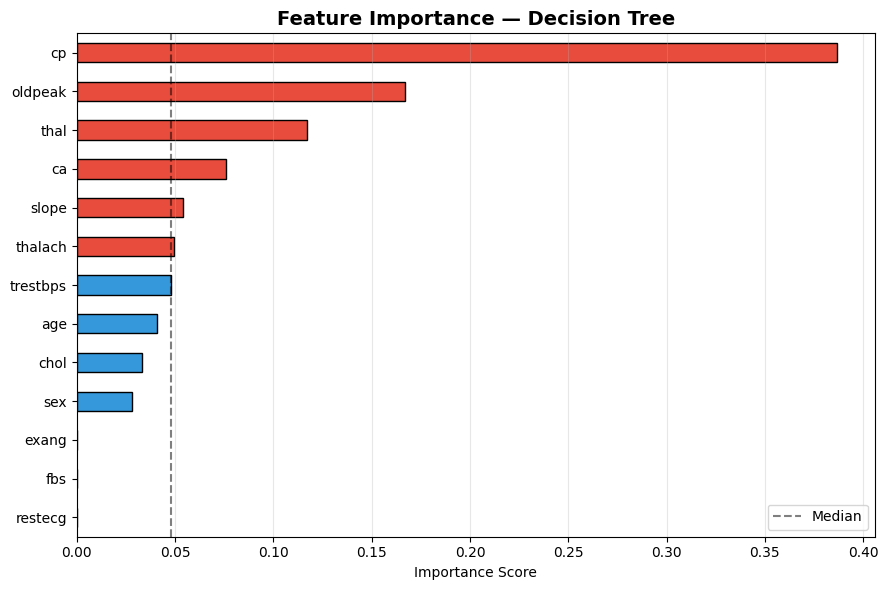


 Red   = HIGH importance features
 Blue  = LOW importance features


In [ ]:
# ─────────────────────────────────────────────
# SECTION 8: Feature Importance
# ─────────────────────────────────────────────

# ── Part A: Decision Tree Feature Importance ─
dt_importance = pd.Series(
    dt.feature_importances_,
    index = feature_names
).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors = ['#e74c3c' if v > dt_importance.median()
          else '#3498db' for v in dt_importance]
dt_importance.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Feature Importance — Decision Tree',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.axvline(x=dt_importance.median(), color='black',
            linestyle='--', alpha=0.5, label='Median')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Red   = HIGH importance features")
print(" Blue  = LOW importance features")

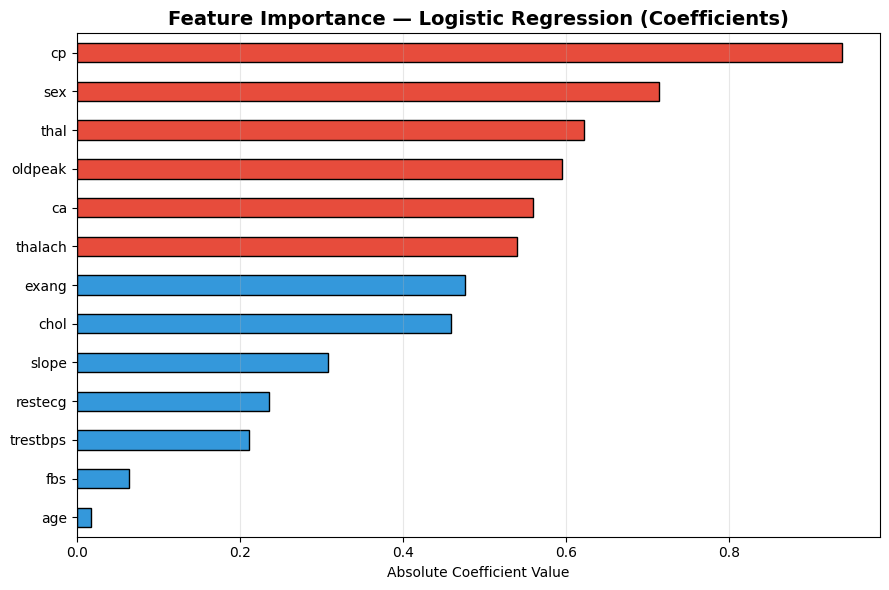

In [ ]:
# ── Part B: Logistic Regression Coefficients ─
lr_importance = pd.Series(
    np.abs(lr.coef_[0]),
    index = feature_names
).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors = ['#e74c3c' if v > lr_importance.median()
          else '#3498db' for v in lr_importance]
lr_importance.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Feature Importance — Logistic Regression (Coefficients)',
          fontsize=14, fontweight='bold')
plt.xlabel('Absolute Coefficient Value')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

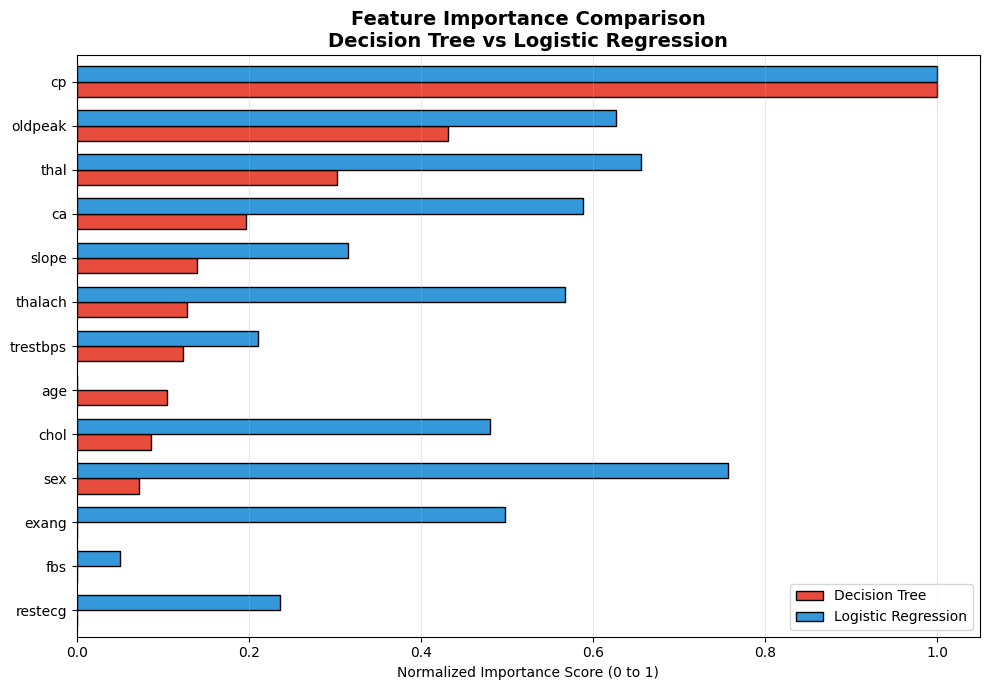


 Top 3 Most Important Features:
   1. cp              → Score: 1.0000
   2. oldpeak         → Score: 0.5294
   3. thal            → Score: 0.4793


In [ ]:
# ── Part C: Combined Feature Importance ──────
# Compare DT and LR importances side by side
importance_df = pd.DataFrame({
    'Decision Tree'      : dt.feature_importances_,
    'Logistic Regression': np.abs(lr.coef_[0])
}, index=feature_names)

# Normalize so both are on same scale (0 to 1)
importance_df = importance_df.apply(
    lambda x: (x - x.min()) / (x.max() - x.min())
)
importance_df = importance_df.sort_values(
    'Decision Tree', ascending=True
)

fig, ax = plt.subplots(figsize=(10, 7))
importance_df.plot(kind='barh', ax=ax,
                   color=['#e74c3c','#3498db'],
                   edgecolor='black', width=0.7)
ax.set_title('Feature Importance Comparison\n'
             'Decision Tree vs Logistic Regression',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Normalized Importance Score (0 to 1)')
ax.grid(axis='x', alpha=0.3)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("\n Top 3 Most Important Features:")
top3 = importance_df.mean(axis=1).sort_values(ascending=False).head(3)
for i, (feat, score) in enumerate(top3.items(), 1):
    print(f"   {i}. {feat:15s} → Score: {score:.4f}")

SECTION 9 — Hyperparameter Tuning

In [ ]:
# ─────────────────────────────────────────────
# SECTION 9: Hyperparameter Tuning (GridSearchCV)
# ─────────────────────────────────────────────

from sklearn.model_selection import GridSearchCV

print(" Finding best settings for each model...")

 Finding best settings for each model...


In [ ]:
# ── Tune Model 1: Decision Tree ───────────────
dt_params = {
    'max_depth'        : [3, 4, 5, 6, 7],
    'min_samples_split': [2, 5, 10],
    'criterion'        : ['gini', 'entropy']
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params, cv=5, scoring='accuracy', n_jobs=-1
)
dt_grid.fit(X_train_scaled, y_train)

print(f" Decision Tree Best Settings:")
print(f"   {dt_grid.best_params_}")
print(f"   Best CV Accuracy: {dt_grid.best_score_:.4f}\n")

 Decision Tree Best Settings:
   {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
   Best CV Accuracy: 0.8015



In [ ]:
# ── Tune Model 2: KNN ─────────────────────────
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 13],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params, cv=5, scoring='accuracy', n_jobs=-1
)
knn_grid.fit(X_train_scaled, y_train)

print(f" KNN Best Settings:")
print(f"   {knn_grid.best_params_}")
print(f"   Best CV Accuracy: {knn_grid.best_score_:.4f}\n")

 KNN Best Settings:
   {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
   Best CV Accuracy: 0.8351



In [ ]:
# ── Tune Model 3: Logistic Regression ─────────
lr_params = {
    'C'      : [0.01, 0.1, 1, 10, 100],
    'solver' : ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_params, cv=5, scoring='accuracy', n_jobs=-1
)
lr_grid.fit(X_train_scaled, y_train)

print(f" Logistic Regression Best Settings:")
print(f"   {lr_grid.best_params_}")
print(f"   Best CV Accuracy: {lr_grid.best_score_:.4f}\n")

 Logistic Regression Best Settings:
   {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
   Best CV Accuracy: 0.8432



In [ ]:
# ── Compare Before vs After Tuning ───────────
print(" Before vs After Hyperparameter Tuning:")

# Tuned models
tuned_models = {
    'Decision Tree'      : dt_grid.best_estimator_,
    'Naive Bayes'        : nb,        # NB has no tuning needed
    'Logistic Regression': lr_grid.best_estimator_,
    'KNN'                : knn_grid.best_estimator_
}

comparison = []
for name in models.keys():
    # Before tuning
    old_pred = models[name].predict(X_test_scaled)
    old_acc  = accuracy_score(y_test, old_pred)

    # After tuning
    new_pred = tuned_models[name].predict(X_test_scaled)
    new_acc  = accuracy_score(y_test, new_pred)

    diff = new_acc - old_acc
    arrow = " Improved" if diff > 0 else (" Same" if diff == 0
                                            else " Dropped")
    comparison.append({
        'Model'        : name,
        'Before Tuning': round(old_acc, 4),
        'After Tuning' : round(new_acc, 4),
        'Change'       : f"{diff:+.4f}  {arrow}"
    })
    print(f"\n {name}")
    print(f"   Before : {old_acc:.4f}")
    print(f"   After  : {new_acc:.4f}  {arrow}")

print("\n Hyperparameter Tuning Complete!")

 Before vs After Hyperparameter Tuning:

 Decision Tree
   Before : 0.7869
   After  : 0.7869   Same

 Naive Bayes
   Before : 0.8197
   After  : 0.8197   Same

 Logistic Regression
   Before : 0.8033
   After  : 0.7869   Dropped

 KNN
   Before : 0.8033
   After  : 0.7869   Dropped

 Hyperparameter Tuning Complete!


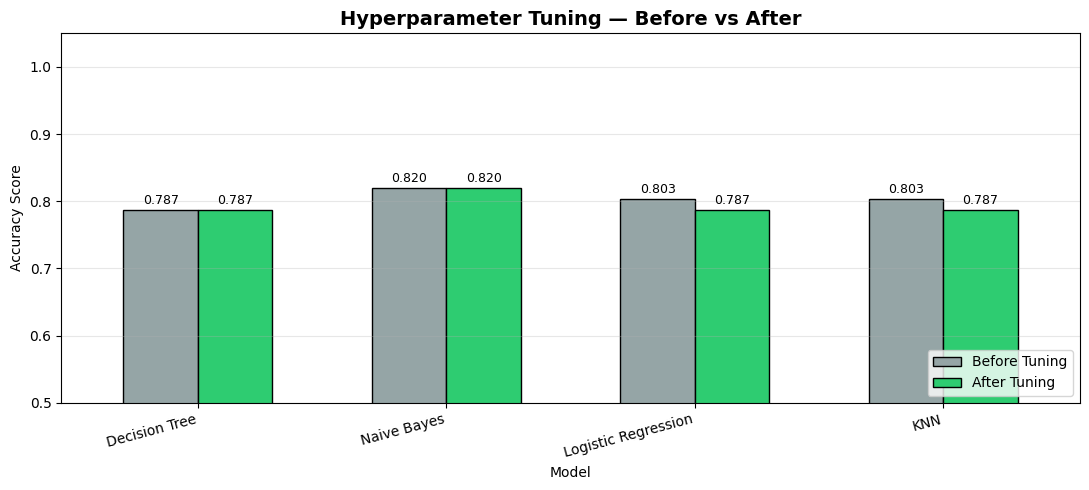

In [ ]:
# ── Before vs After Bar Chart ─────────────────
comp_df = pd.DataFrame(comparison).set_index('Model')
comp_plot = comp_df[['Before Tuning', 'After Tuning']]

ax = comp_plot.plot(kind='bar', figsize=(11, 5),
                    color=['#95a5a6','#2ecc71'],
                    edgecolor='black', width=0.6)

plt.title('Hyperparameter Tuning — Before vs After',
          fontsize=14, fontweight='bold')
plt.ylabel('Accuracy Score')
plt.ylim(0.5, 1.05)
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.legend(loc='lower right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f',
                 fontsize=9, padding=2)
plt.tight_layout()
plt.show()

SECTION 10 — Final Project Summary

In [ ]:
# ─────────────────────────────────────────────
# SECTION 10: Final Project Summary
# ─────────────────────────────────────────────

# Print final best model
print("FINAL BEST MODEL:")
final_results = []
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    final_results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred),  4),
        'F1-Score' : round(f1_score(y_test, y_pred),        4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob),   4)
    })

final_df = pd.DataFrame(final_results).set_index('Model')
print(final_df.to_string())

best_model = final_df['F1-Score'].idxmax()
print(f"\n Best Model : {best_model}")
print(f"   F1-Score : {final_df.loc[best_model, 'F1-Score']}")
print(f"   Accuracy : {final_df.loc[best_model, 'Accuracy']}")
print(f"   ROC-AUC  : {final_df.loc[best_model, 'ROC-AUC']}")

FINAL BEST MODEL:
                     Accuracy  F1-Score  ROC-AUC
Model                                           
Decision Tree          0.7869    0.8169   0.8561
Naive Bayes            0.8197    0.8451   0.8755
Logistic Regression    0.7869    0.8219   0.8820
KNN                    0.7869    0.8219   0.9140

 Best Model : Naive Bayes
   F1-Score : 0.8451
   Accuracy : 0.8197
   ROC-AUC  : 0.8755
